
=== VERDADEIRO vs APRENDIDO (GP correto: RBF + WhiteKernel) ===
A_true           = 2.0000
ell_true         = 1.6000
alpha_true       = 0.3600  (sigma_white_true^2)

Aprendido:
A_hat            = 1.3400
ell_hat          = 1.5859
alpha_hat        = 0.0119

Kernel aprendido:
1.34**2 * RBF(length_scale=1.59) + WhiteKernel(noise_level=0.0119)

=== Resíduos (treino) ===
mean(resid_norm) ~ -0.0139  (ideal ~ 0)
std(resid_norm)  ~ 2.5382  (ideal ~ 1)
ACF(resid_norm) lags 0..6: [ 1.    -0.862  0.624 -0.452  0.315 -0.201  0.078]

=== Modelo 'errado' (sem WhiteKernel) ===
Kernel aprendido (sem ruído explícito):
1**2 * RBF(length_scale=1)


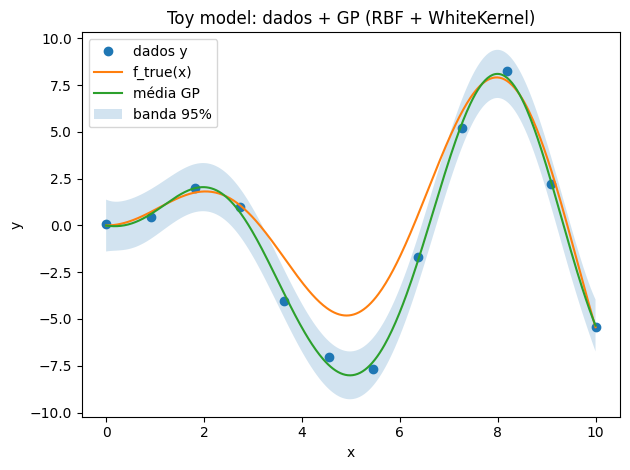

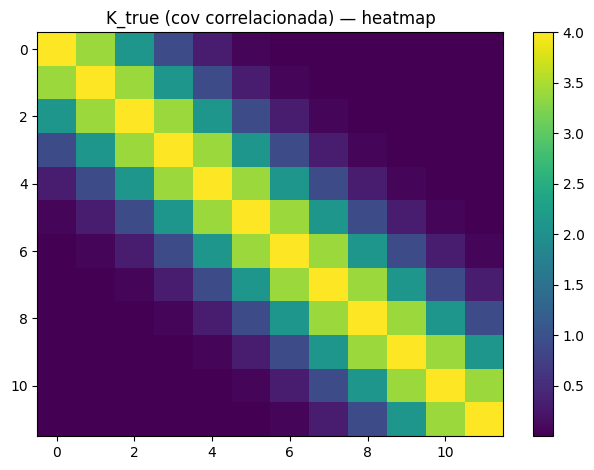

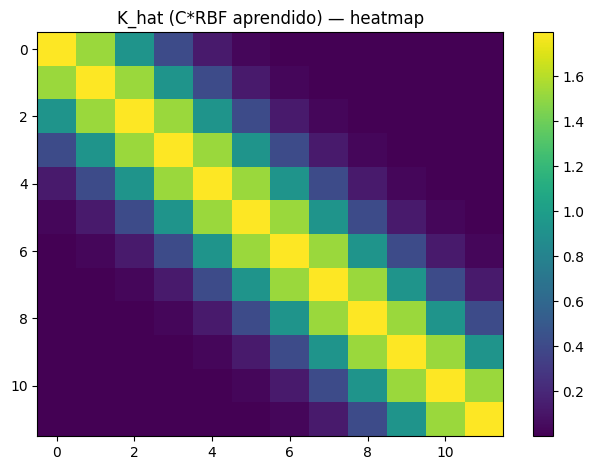

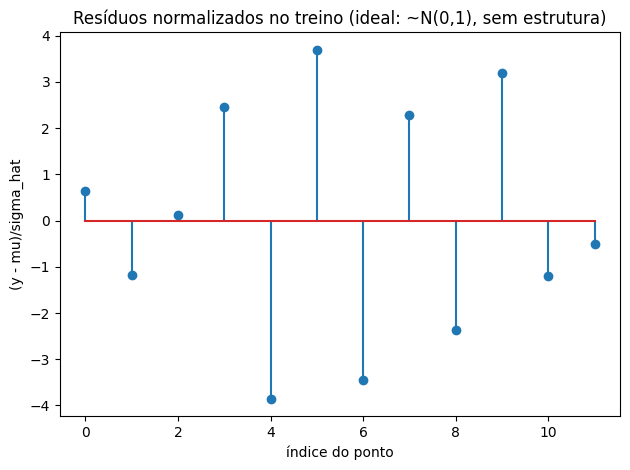

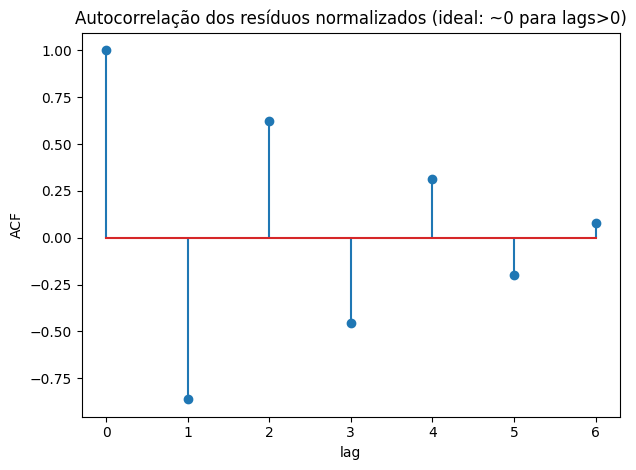

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

# ---------------------------
# 1) Config do toy model
# ---------------------------
SEED = 7
rng = np.random.default_rng(SEED)

n = 12
X = np.linspace(0.0, 10.0, n).reshape(-1, 1)
x = X[:, 0]

def f_true(x):
    return x * np.sin(x)

# Kernel verdadeiro para gerar a parte correlacionada g(x)
A_true = 2.0
ell_true = 1.6

def rbf_covariance_1d(x, A, ell):
    # K_ij = A^2 * exp( - (xi-xj)^2 / (2 ell^2) )
    dx = x[:, None] - x[None, :]
    K = (A**2) * np.exp(-(dx**2) / (2.0 * ell**2))
    return K

K_true = rbf_covariance_1d(x, A_true, ell_true)

# "Jitter" numérico para garantir SPD
jitter = 1e-10
K_true_j = K_true + jitter * np.eye(n)

# Ruído branco i.i.d. verdadeiro
sigma_white_true = 0.60
alpha_true = sigma_white_true**2  # variância

# ---------------------------
# 2) Gerar dados via Cholesky
# ---------------------------
L = np.linalg.cholesky(K_true_j)

z = rng.normal(0.0, 1.0, size=n)     # i.i.d.
g = L @ z                             # correlacionado: g ~ N(0, K_true)

eps = rng.normal(0.0, sigma_white_true, size=n)  # white noise

y = f_true(x) + g + eps

# ---------------------------
# 3) Ajustar GP "correto": RBF + WhiteKernel
# ---------------------------
# kernel = (const * RBF) + WhiteKernel
kernel0 = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
          + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-6, 10.0))

gp = GaussianProcessRegressor(
    kernel=kernel0,
    alpha=0.0,                 # aqui deixamos o WhiteKernel aprender o white noise
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=SEED,
)

gp.fit(X, y)

# Extrair hiperparâmetros aprendidos
kernel_fit = gp.kernel_
# Para kernel do tipo: C * RBF + WhiteKernel
# A constante sai como "constant_value"
# O RBF tem "length_scale"
# O WhiteKernel tem "noise_level" (isso é a variância do ruído!)
try:
    const_val = kernel_fit.k1.k1.constant_value
    ell_hat = kernel_fit.k1.k2.length_scale
    alpha_hat = kernel_fit.k2.noise_level
except Exception:
    const_val = None
    ell_hat = None
    alpha_hat = None

A_hat = np.sqrt(const_val) if const_val is not None else None

print("\n=== VERDADEIRO vs APRENDIDO (GP correto: RBF + WhiteKernel) ===")
print(f"A_true           = {A_true:.4f}")
print(f"ell_true         = {ell_true:.4f}")
print(f"alpha_true       = {alpha_true:.4f}  (sigma_white_true^2)")

print("\nAprendido:")
print(f"A_hat            = {A_hat:.4f}" if A_hat is not None else "A_hat: (não extraído)")
print(f"ell_hat          = {float(ell_hat):.4f}" if ell_hat is not None else "ell_hat: (não extraído)")
print(f"alpha_hat        = {float(alpha_hat):.4f}" if alpha_hat is not None else "alpha_hat: (não extraído)")
print("\nKernel aprendido:")
print(kernel_fit)

# ---------------------------
# 4) Predição + banda (troque z se quiser 68/95/99%)
# ---------------------------
X_star = np.linspace(0.0, 10.0, 400).reshape(-1, 1)
mu, std = gp.predict(X_star, return_std=True)

z95 = 1.96  # 95%
lower = mu - z95 * std
upper = mu + z95 * std

# ---------------------------
# 5) Diagnóstico de resíduos (no treino)
# ---------------------------
mu_train = gp.predict(X)
resid = y - mu_train

# Normaliza pelo ruído i.i.d. aprendido (variância -> desvio padrão)
# Se alpha_hat ficou None por algum motivo, caímos no alpha_true só pra não quebrar
sigma_hat = np.sqrt(alpha_hat) if alpha_hat is not None else np.sqrt(alpha_true)
resid_norm = resid / sigma_hat

def autocorr_1d(v, max_lag=6):
    v = np.asarray(v)
    v = v - v.mean()
    denom = np.dot(v, v)
    ac = []
    for lag in range(max_lag + 1):
        num = np.dot(v[:-lag], v[lag:]) if lag > 0 else np.dot(v, v)
        ac.append(num / denom if denom > 0 else np.nan)
    return np.array(ac)

acf = autocorr_1d(resid_norm, max_lag=6)

print("\n=== Resíduos (treino) ===")
print(f"mean(resid_norm) ~ {resid_norm.mean():.4f}  (ideal ~ 0)")
print(f"std(resid_norm)  ~ {resid_norm.std(ddof=1):.4f}  (ideal ~ 1)")
print("ACF(resid_norm) lags 0..6:", np.array2string(acf, precision=3))

# ---------------------------
# 6) Ajuste "errado" (sem WhiteKernel) só para contraste
#    Aqui a ideia é: o modelo não tem um canal explícito pra i.i.d.,
#    então ele tende a tentar explicar tudo via correlação.
# ---------------------------
kernel_wrong0 = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

gp_wrong = GaussianProcessRegressor(
    kernel=kernel_wrong0,
    alpha=0.0,  # sem nugget i.i.d. explícito
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=SEED,
)
gp_wrong.fit(X, y)

print("\n=== Modelo 'errado' (sem WhiteKernel) ===")
print("Kernel aprendido (sem ruído explícito):")
print(gp_wrong.kernel_)

# ---------------------------
# 7) Plots
# ---------------------------
plt.figure()
plt.plot(x, y, "o", label="dados y")
plt.plot(X_star[:, 0], f_true(X_star[:, 0]), label="f_true(x)")
plt.plot(X_star[:, 0], mu, label="média GP")
plt.fill_between(X_star[:, 0], lower, upper, alpha=0.2, label="banda 95%")
plt.title("Toy model: dados + GP (RBF + WhiteKernel)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()

# Heatmap: K_true e K_hat (parte correlacionada)
# K_hat aqui é só do pedaço C*RBF (sem WhiteKernel)
# Vamos construir K_hat usando os hiperparâmetros aprendidos
plt.figure()
plt.title("K_true (cov correlacionada) — heatmap")
plt.imshow(K_true, aspect="auto")
plt.colorbar()
plt.tight_layout()

if A_hat is not None and ell_hat is not None:
    K_hat = rbf_covariance_1d(x, A_hat, float(ell_hat))
    plt.figure()
    plt.title("K_hat (C*RBF aprendido) — heatmap")
    plt.imshow(K_hat, aspect="auto")
    plt.colorbar()
    plt.tight_layout()

# Resíduos normalizados + ACF
plt.figure()
plt.stem(range(len(resid_norm)), resid_norm)
plt.title("Resíduos normalizados no treino (ideal: ~N(0,1), sem estrutura)")
plt.xlabel("índice do ponto")
plt.ylabel("(y - mu)/sigma_hat")
plt.tight_layout()

plt.figure()
plt.stem(range(len(acf)), acf)
plt.title("Autocorrelação dos resíduos normalizados (ideal: ~0 para lags>0)")
plt.xlabel("lag")
plt.ylabel("ACF")
plt.tight_layout()

plt.show()